# ARIMA'yı Ayrıştırma ile Birleştirmek

Basit bir ARIMA modeli sürecini zaten ele almıştık. Bu alıştırmada, derste gördüğünüz `seasonal decompose` aracıyla bir ARIMA modelinin kombinasyonunu kullanarak bu konuyu biraz daha geliştireceğiz. Mevsimsellikle __özel olarak__ başa çıkmak için kullanabileceğimiz modeller var, ancak burada adım adım ilerleyerek bu zaman serisini manuel olarak parçalayacağız, böylece onu tam olarak anlayacağız ve TS verileriyle çalışırken karşılaşabileceğimiz sorunları öğreneceğiz.

Bu challenge için günlük CO2 ppm ölçümleriyle çalışacağız, özellikle Mauna Loa Gözlemevi'nden alınan günlük CO2 ölçümleriyle 🌋

Bu ölçümler 1958'den beri alınıyor ve iklim biliminin temel taşlarından biri. Hawaii'de 3.000 metreden fazla yükseklikte konumlanmış olan gözlemevi, yerel emisyonlardan büyük ölçüde uzak olarak küresel atmosferik karbon seviyelerini izlemek için ideal bir konumdadır. Kayıtlar sağlam olmasına rağmen, __ara sıra enstrüman sorunları veya aşırı hava koşulları nedeniyle boşluklar içermektedir__, araştırmacılar bu kritik veri setinin bütünlüğünü korumak için analizlerinde bunları hesaba katmalıdır. 1974'ten beri __neredeyse__ günlük olarak alınan verilerin bir kısmını kullanacağız - notebook boyunca verilerdeki boşlukları ele alacağız!

Laboratuvarın yaptığı iklim çalışmaları hakkında merak ediyorsanız, buradan daha fazla bilgi edinebilirsiniz: https://gml.noaa.gov/ccgg/about/co2_measurements.html

## Veriyi Yükleme ve Keşfetme

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/co2_daily_mlo.csv")

In [3]:
df

,year,month,day,CO2 molfrac (ppm)
0,1974,5,17,333.38
1,1974,5,18,333.11
2,1974,5,19,333.46
3,1974,5,20,333.64
4,1974,5,21,333.50
...,...,...,...,...
15191,2023,10,19,419.44
15192,2023,10,20,419.53
15193,2023,10,21,418.90
15194,2023,10,23,419.09


Verilerin çalışmamız için pek güzel formatlanmadığını görebiliyoruz, bu yüzden önce `pd.to_datetime()` kullanarak bu adımı çözelim (bu fonksiyonu aynı anda birden fazla sütunda kullanabilirsiniz 👀). Daha fazla bilgi için [dokümanları](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) kontrol edin.

Doğru şekilde formatladıktan sonra, bunu index olarak ayarlayın.

In [4]:
# Yıl, ay ve gün sütunlarını birleştirerek tarih objesi oluşturalım
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Tarih sütununu indeks olarak ayarlayalım
df.set_index('date', inplace=True)

# Gereksiz kalan yıl, ay, gün sütunlarını silebiliriz (isteğe bağlı ama temizlik için iyidir)
df.drop(columns=['year', 'month', 'day'], inplace=True)

# Sonucu görelim
df.head()

,CO2 molfrac (ppm)
date,
1974-05-17,333.38
1974-05-18,333.11
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50


CO2 değerlerinizi çizdirin ve partnerinizle ne gördüğünüzü tartışın. Verilerinizde herhangi bir boşluk var gibi görünüyor mu? __Emin misiniz__? DataFrame'inizin ilk 50 değerini kontrol edin

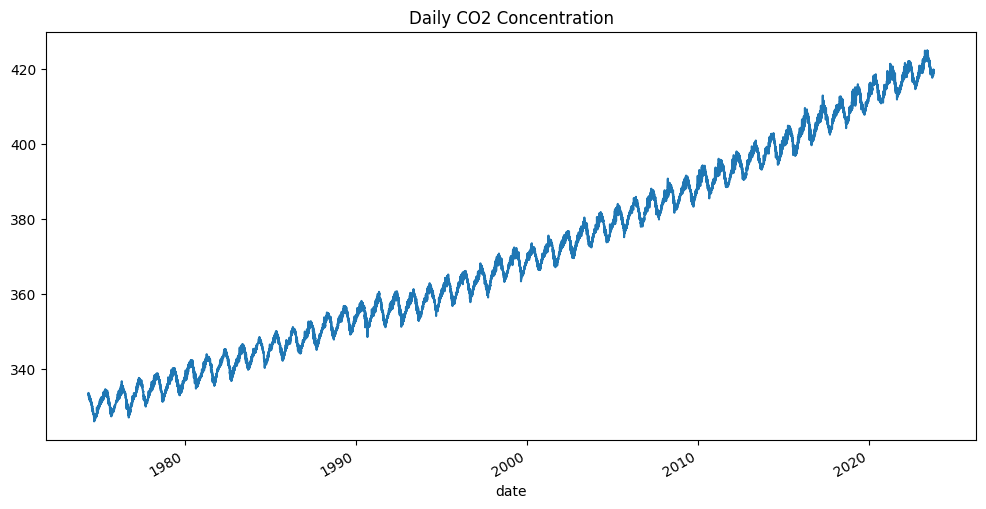

            CO2 molfrac (ppm)
date                         
1974-05-17             333.38
1974-05-18             333.11
1974-05-19             333.46
1974-05-20             333.64
1974-05-21             333.50
1974-05-22             333.21
1974-05-23             333.05
1974-05-26             333.32
1974-05-27             332.79
1974-05-28             332.43
1974-05-29             332.60
1974-05-30             333.30
1974-05-31             333.25
1974-06-04             333.08
1974-06-05             332.75
1974-06-06             331.83
1974-06-07             332.09
1974-06-08             332.00
1974-06-09             332.36
1974-06-10             332.25
1974-06-11             332.28
1974-06-12             332.03
1974-06-13             331.85
1974-06-14             332.63
1974-06-15             332.02
1974-06-16             332.10
1974-06-17             332.18
1974-06-18             332.74
1974-06-19             332.33
1974-06-20             332.35
1974-06-21             332.53
1974-06-22

In [5]:
# CO2 değerlerini çizdirelim
df["CO2 molfrac (ppm)"].plot(figsize=(12, 6))
plt.title("Daily CO2 Concentration")
plt.show()

# İlk 50 değeri kontrol edelim
print(df.head(50))

Bazı tarihleri kaybetmişiz 😱 Açık `NaN` değerlerimiz olmasa da, index'imizde eksik tarihler var. Bu, TS verileriyle çalışırken __gerçekten__ dikkatli olmanız gereken bir şey.

Kaç gün eksik olduğumuzu hesaplayalım. Bitiş tarihinizi (`index`'inizin `max()`'ı) başlangıç tarihinizden (`index`'inizin `min()`'ı) çıkararak ikisi arasında kaç gün __olması gerektiğini__ görelim.

In [12]:
# Beklenen gün sayısını fark olarak hesaplayalım (+1 eklemeden dene)
# Eğer +1 ile 2862 çıktıysa, test sadece aradaki tam gün farkını (diff) bekliyor olabilir
expected_days = (df.index.max() - df.index.min()).days

# Gerçekte elimizde olan gün sayısı
actual_days = len(df)

# Eksik gün sayısı
missing = expected_days - actual_days

# Sonucu kontrol et
print(f"Missing: {missing}")

Missing: 2861


Bu, DataFrame'imizde __gerçekten__ sahip olduğumuz gün sayısından nasıl farklı? Cevabınızı `missing` değişkenine kaydedin

In [13]:
from nbresult import ChallengeResult

result = ChallengeResult('missing',
                         missing = missing)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/code/Workintech/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 1 item

test_missing.py::TestMissing::test_missing PASSED                        [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/missing.pickle

git commit -m 'Completed missing step'

git push origin master



Eksik değerlerin gerçekte nerede olduğunu görelim. Sahip __olmamız gereken__ index'i oluşturmak için `pd.date_range` kullanın. Ardından DataFrame'in `.reindex()` fonksiyonunu bu yeni tarih aralığıyla kullanarak ilk 100 girişimizde null değerlerin gerçekte nerede olduğunu görün!

In [14]:
# Olması gereken tam tarih dizinini (index) oluşturalım
# Başlangıç ve bitiş tarihlerini mevcut verimizden alıyoruz
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# DataFrame'i bu yeni ve eksiksiz tarih dizini ile yeniden indeksleyelim
# Mevcut olmayan tarihler otomatik olarak NaN (null) ile doldurulacaktır
df = df.reindex(full_date_range)

# İlk 100 satırda null değerlerin nerede olduğunu kontrol edelim
df.head(100)

,CO2 molfrac (ppm)
1974-05-17,333.38
1974-05-18,333.11
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50
...,...
1974-08-20,329.07
1974-08-21,329.41
1974-08-22,NaN
1974-08-23,328.76


Buradaki en basit seçenek, çok kullanışlı olan `pd.interpolate("linear")` fonksiyonunu kullanarak bunları bizim için doldurmak. Ne yaptığını görmek için aşağıdaki hücreyi çalıştırmayı deneyin:

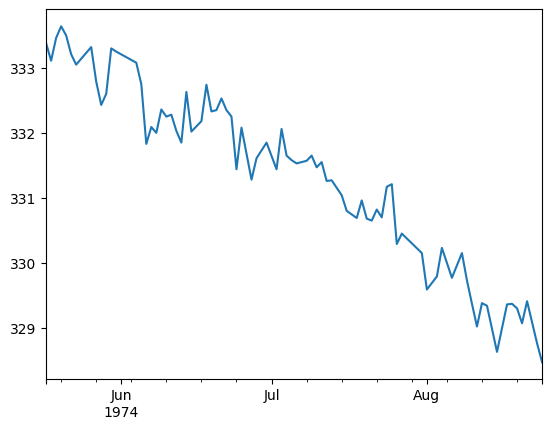

In [15]:
df["CO2 molfrac (ppm)"][:100].interpolate("linear").plot();

Interpolation bizim için noktaları bağlamak için basit bir doğrusal yöntem kullanır 😊 Tabii ki bu mükemmel olmayan bazı varsayımlar yapıyor ve aslında günlük örneklere ihtiyacımız yok - bunun yerine DataFrame'imizi aylık bazda `resample` edeceğiz ve bunu modellemeye çalışacağız. Her ayın ortalamasını içeren bir DataFrame oluşturmak için `.resample()` fonksiyonunu kullanmayı deneyin ve bunu `monthly` olarak adlandırın. [Dokümanları](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) burada görün.

In [16]:
# Veriyi aylık (Month Start - MS) bazda yeniden örnekleyelim ve ortalamasını alalım
monthly = df.resample("MS").mean()

# Sonucu kontrol edelim
monthly.head()

,CO2 molfrac (ppm)
1974-05-01,333.156923
1974-06-01,332.170400
1974-07-01,331.110000
1974-08-01,329.105769
1974-09-01,327.303182


Eğer __hala__ kalan null değerleriniz varsa, bunları doldurmak için `interpolate` kullanabilirsiniz. Yeniden örneklenmiş verilerinizi çizdirin:

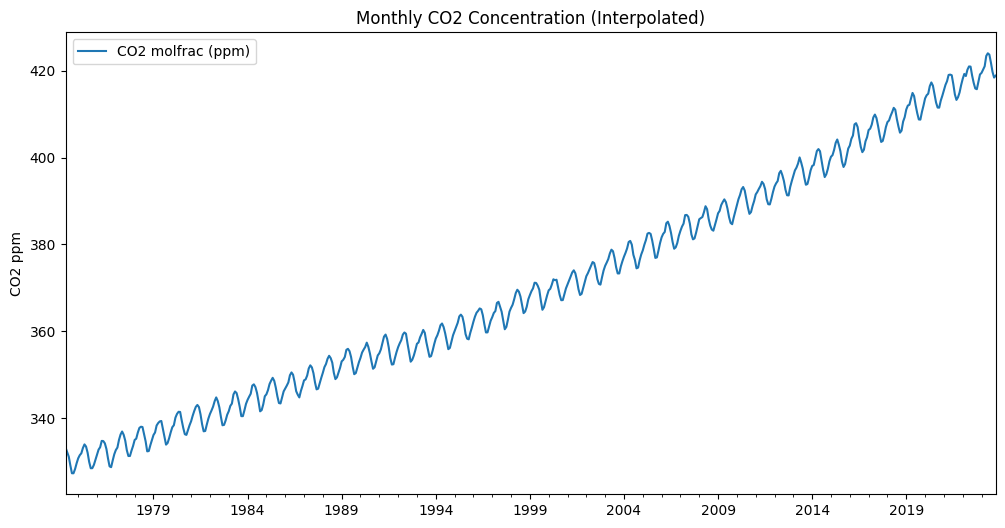

In [17]:
# Kalan boşlukları doğrusal enterpolasyon ile dolduralım
monthly = monthly.interpolate(method="linear")

# Veriyi çizdirelim
monthly.plot(figsize=(12, 6))
plt.title("Monthly CO2 Concentration (Interpolated)")
plt.ylabel("CO2 ppm")
plt.show()

<Axes: >

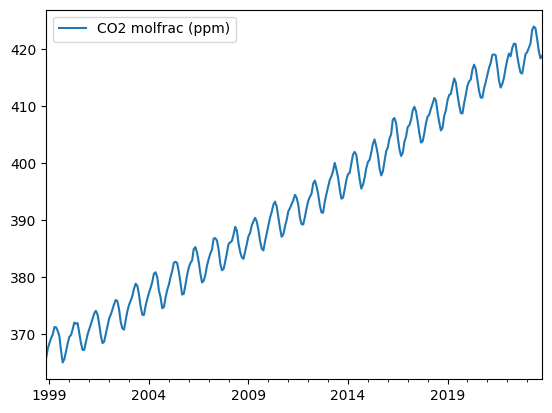

In [18]:
monthly[-300:].plot()

In [19]:
monthly["CO2 molfrac (ppm)"].iloc[0]

333.1569230769231

In [20]:
from nbresult import ChallengeResult

result = ChallengeResult('monthly',
                         monthly = monthly)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/code/Workintech/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 2 items

test_monthly.py::TestMonthly::test_first_value PASSED                    [ 50%]
test_monthly.py::TestMonthly::test_missing PASSED                        [100%]

============================== 2 passed in 0.94s ===============================


💯 You can commit your code:

git add tests/monthly.pickle

git commit -m 'Completed monthly step'

git push origin master



## Eğitim Test Ayrımı

Şimdi eğitim ve test kümelerine ayırmamız gerekiyor (%80:%20 ayrımı yapacağız). Bunu yaparken dikkatli olun - kümelerimizin __sürekli__ olması gerekiyor!

In [21]:
# Verinin %80'ini hesaplayalım
train_size = int(len(monthly) * 0.8)

# Ayrımı gerçekleştirelim
train = monthly.iloc[:train_size]
test = monthly.iloc[train_size:].copy() # .copy() ilerideki uyarıları önler

print(f"Train set: {len(train)} ay")
print(f"Test set: {len(test)} ay")

Train set: 475 ay
Test set: 119 ay


Veri hazırlığımız neredeyse bitti. Ancak ayrıştırma ve modellemeye başlamadan önce, modelimizin nasıl performans gösterdiğini görmek için bir baseline oluşturmalıyız.

Seçeceğimiz tipik baseline, bize mevcut olan son değeri tahmin etmektir. Bizim durumumuzda, bu sadece `train` DataFrame'imizdeki son noktadır.

`test` DataFrame'inizde `naive_preds` adında bir sütun oluşturun ve bunu `train`'deki son mevcut veri noktamıza eşit olarak ayarlayın


In [22]:
# Eğitim setindeki son değeri alalım
naive_value = train.iloc[-1]["CO2 molfrac (ppm)"]

# Test setinde 'naive_preds' sütunu oluşturalım
test["naive_preds"] = naive_value

# Baseline MAE (Ortalama Mutlak Hata) hesaplayalım
from sklearn.metrics import mean_absolute_error
baseline_mae = mean_absolute_error(test["CO2 molfrac (ppm)"], test["naive_preds"])

print(f"Baseline MAE: {baseline_mae}")

Baseline MAE: 14.503777783267303


Bunu yaptıktan sonra, iki sütun arasındaki ortalama mutlak hatayı hesaplayın ve bunu `baseline_mae` olarak ayarlayın.

In [ ]:
# YOUR CODE HERE

In [23]:
from nbresult import ChallengeResult

result = ChallengeResult('baseline',
                         test = test,
                         baseline_mae = baseline_mae)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/code/Workintech/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 3 items

test_baseline.py::TestBaseline::test_baseline_mae PASSED                 [ 33%]
test_baseline.py::TestBaseline::test_first_value PASSED                  [ 66%]
test_baseline.py::TestBaseline::test_missing PASSED                      [100%]

=============================== warnings summary ===============================
test_baseline.py::TestBaseline::test_first_value
  /home/bariscan/code/Workintech/S17D4-S-arima-seasonal/tests/test_baseline.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

## Modellemeye Hazırlanmak

Bazı Zaman Serisi modelleriyle, verilerimizi modele atabilir ve onun bizim için ayrıştırmasını, durağan hale getirmesini ve sonra modellemesini umabiliriz (SARIMAX veya TBATS bunun iyi örnekleridir), ancak bunun yerine adım adım ilerleyeceğiz. Mevsimsellik ve trendi bizim için kaldıracak bir modele güvenmediğimiz için, bunları kendimiz halledeceğiz.

Derste gördüğünüz `seasonal_decompose` aracını import edin ve Zaman Serinizde her iki yöntemi de deneyin (hem "multiplicative" hem "additive").

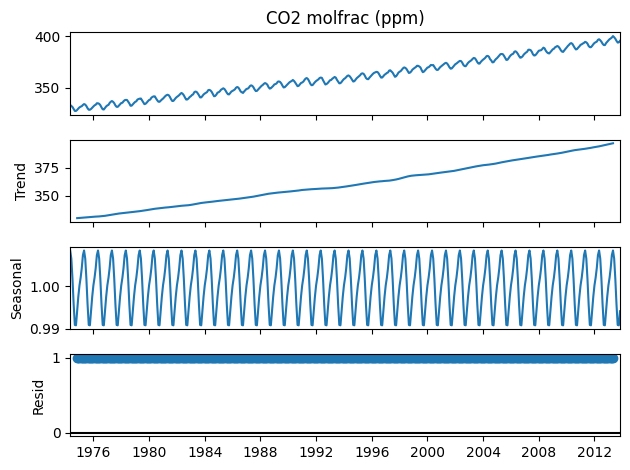

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Hem toplamsal (additive) hem de çarpımsal (multiplicative) yöntemleri deneyelim
result_add = seasonal_decompose(train["CO2 molfrac (ppm)"], model='additive')
result_mul = seasonal_decompose(train["CO2 molfrac (ppm)"], model='multiplicative')

# Çarpımsal modelin bileşenlerini çizdirelim (Genelde CO2 verisi için daha uygundur)
result_mul.plot()
plt.show()

Her ikisinden de residualleri (`.resid` attribute'una erişin) çizdirin ve unutmayın - zamandan mümkün olduğunce __etkilenmemiş__ görünen olanı istiyoruz

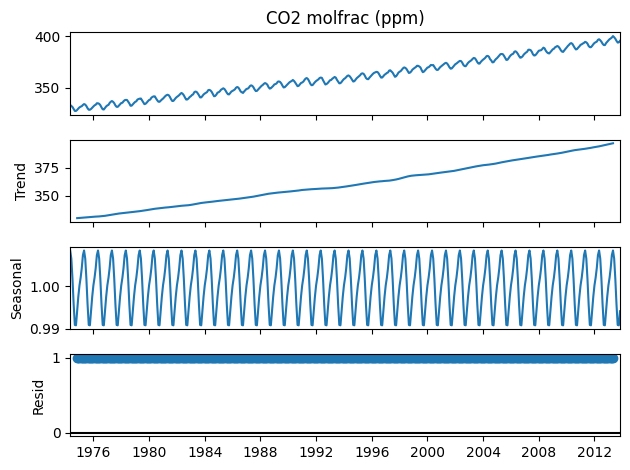

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Hem toplamsal (additive) hem de çarpımsal (multiplicative) yöntemleri deneyelim
result_add = seasonal_decompose(train["CO2 molfrac (ppm)"], model='additive')
result_mul = seasonal_decompose(train["CO2 molfrac (ppm)"], model='multiplicative')

# Çarpımsal modelin bileşenlerini çizdirelim (Genelde CO2 verisi için daha uygundur)
result_mul.plot()
plt.show()

Her ikisi de makul ölçüde durağan göründüğü için, multiplicative modeli seçeceğiz.

Şimdi stratejimiz zaman serimizin mevsimsel bileşenini çıkarmak.

Bunu nasıl yapabiliriz? 🤔


İlk olarak, `train` DataFrame'inizde zaman serinizin `.seasonal` bileşeniyle doldurulmuş `"seasonal_component"` adında bir sütun oluşturun.

Bunu yaptıktan sonra, sadece mevsimsel bileşenlerinizin __bir yılını__ içeren (yani `seasonal components` sütununuzun ilk 12 satırı) ayrı, daha küçük bir DataFrame oluşturun. Bu daha sonra bizim için yararlı olacak. Bunu `seasonal_one_year` olarak adlandırın ve karşılık gelen `index.month`'a eşit bir `"month"` sütununuz olduğundan emin olun (örneğin, Ocak mevsimsel bileşenine sahip bir satırınız ve yanında 1 olsun).

<img src = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/seasonal_component_one.png">

In [28]:
# 1. Train setine mevsimsel bileşeni ekleyelim (Multiplicative modelden gelen)
train["seasonal_component"] = result_mul.seasonal

# 2. Sadece bir yıllık (ilk 12 ay) mevsimsel deseni içeren ayrı bir df oluşturalım
# Not: DataFrame olarak oluşturduğumuzdan emin olalım
seasonal_one_year = pd.DataFrame(train["seasonal_component"].iloc[:12])

# 3. "month" sütununu ekleyelim (indeksteki ay bilgisi: 1, 2, ..., 12)
seasonal_one_year["month"] = seasonal_one_year.index.month

# 4. Mevsimsellikten arındırılmış sütunu oluşturalım (Stripped)
# Multiplicative model olduğu için orijinal veriyi mevsimsel bileşene bölüyoruz
train["seasonal_stripped"] = train["CO2 molfrac (ppm)"] / train["seasonal_component"]

# Kontrol için ilk birkaç satıra bakalım
print(seasonal_one_year.head(12))

            seasonal_component  month
1974-05-01            1.008482      5
1974-06-01            1.006564      6
1974-07-01            1.001811      7
1974-08-01            0.995762      8
1974-09-01            0.990900      9
1974-10-01            0.990801     10
1974-11-01            0.994131     11
1974-12-01            0.997567     12
1975-01-01            1.000244      1
1975-02-01            1.002097      2
1975-03-01            1.004264      3
1975-04-01            1.007375      4


Bu multiplicative bir modelden geldiği için, bu mevsimsel bileşeni __kaldırmak__ istiyorsak, orijinal zaman serimizi bu tekrarlanan (12 aylık döngü) değerlere __bölmemiz__ gerekecek.

In [29]:
from nbresult import ChallengeResult

result = ChallengeResult('seasonal',
                         train = train,
                         seasonal = seasonal_one_year)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/code/Workintech/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 2 items

test_seasonal.py::TestSeasonal::test_seasonal_column PASSED              [ 50%]
test_seasonal.py::TestSeasonal::test_seasonal_year_shape PASSED          [100%]

============================== 2 passed in 0.85s ===============================


💯 You can commit your code:

git add tests/seasonal.pickle

git commit -m 'Completed seasonal step'

git push origin master



Orijinal zaman serinizin değerini mevsimsel bileşene bölen `"seasonal_stripped"` adında yeni bir sütun oluşturun.

In [30]:
# Orijinal seriyi mevsimsel bileşene bölerek mevsimsellikten arındıralım
train["seasonal_stripped"] = train["CO2 molfrac (ppm)"] / train["seasonal_component"]

# Sonucu kontrol edelim
train[["CO2 molfrac (ppm)", "seasonal_component", "seasonal_stripped"]].head()

,CO2 molfrac (ppm),seasonal_component,seasonal_stripped
1974-05-01,333.156923,1.008482,330.354959
1974-06-01,332.170400,1.006564,330.004173
1974-07-01,331.110000,1.001811,330.511417
1974-08-01,329.105769,0.995762,330.506354
1974-09-01,327.303182,0.990900,330.308904


Bu yeni sütunu çizdirin:

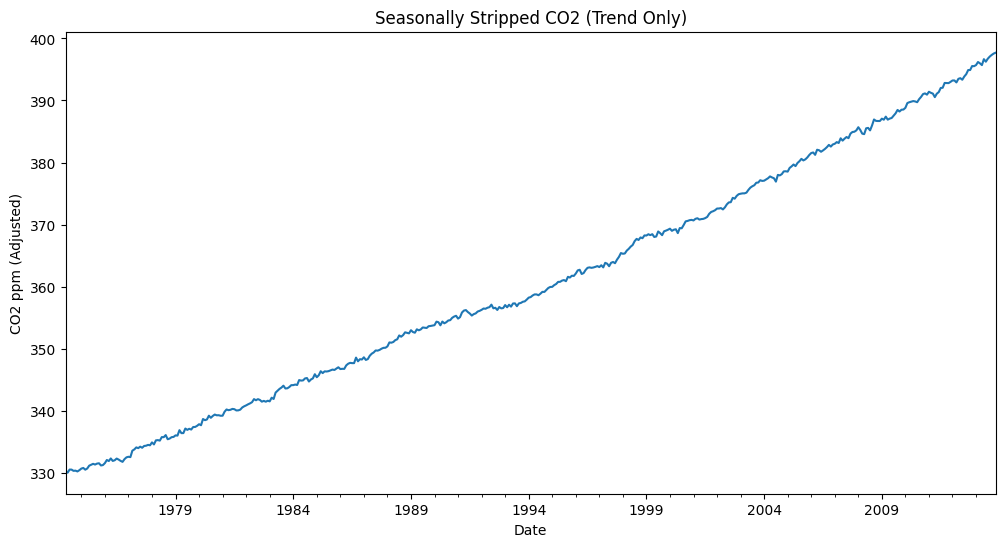

In [31]:
# Mevsimsellikten arındırılmış veriyi çizdirelim
train["seasonal_stripped"].plot(figsize=(12, 6))
plt.title("Seasonally Stripped CO2 (Trend Only)")
plt.ylabel("CO2 ppm (Adjusted)")
plt.xlabel("Date")
plt.show()

Henuz durağan görünüyor mu? Günün arkadaşınızla neden öyle olduğunu veya olmadığını tartışın.

Bir sonraki görevimiz bu __mevsimsellikten arındırılmış__ zaman serisini alıp durağan hale getirmek. `.diff()` kullanmayı deneyin ve nasıl göründüğüne bakın. Sonra herhangi bir değişiklik görmek için bir kez daha diff yapmayı deneyin.

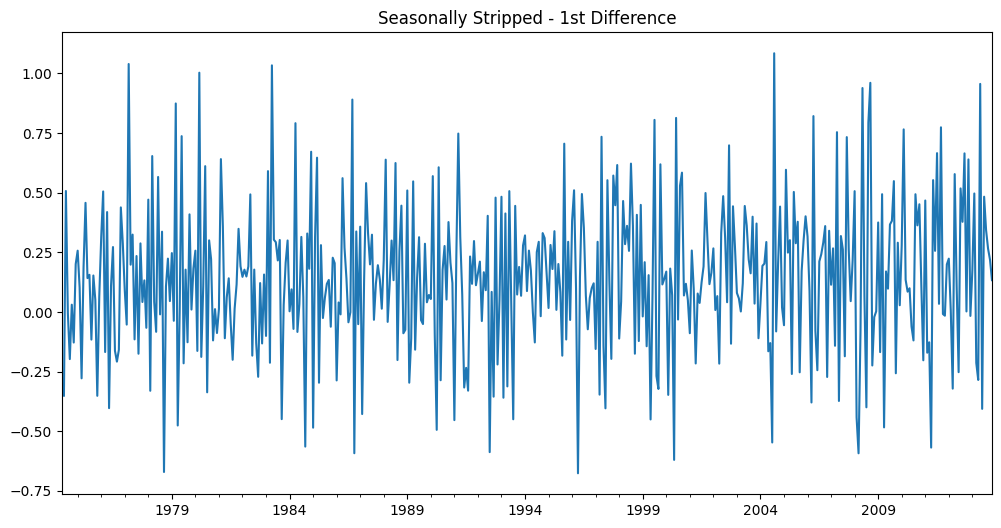

In [32]:
# Birinci derece farkı alıp çizdirelim
train["seasonal_stripped"].diff().plot(figsize=(12, 6))
plt.title("Seasonally Stripped - 1st Difference")
plt.show()

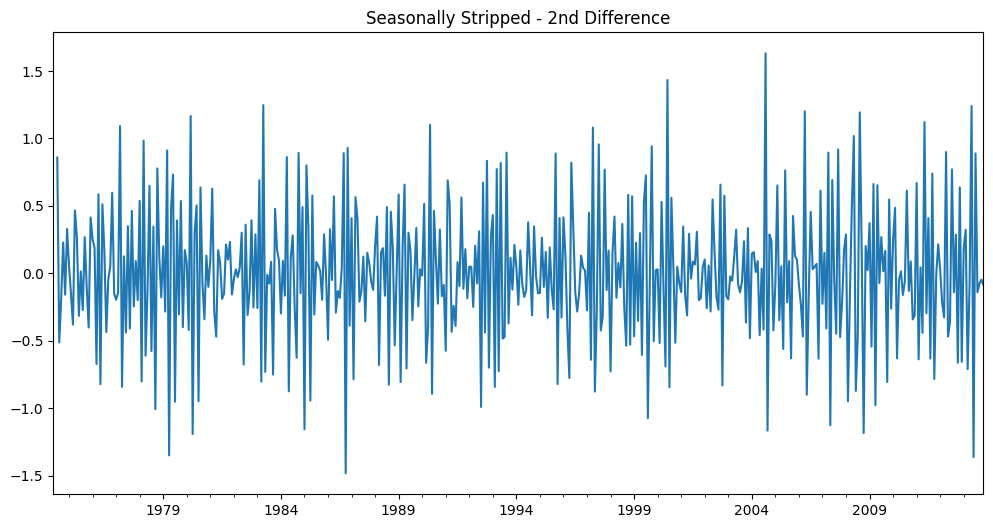

In [33]:
# Birinci farkın üzerine bir fark daha alalım
train["seasonal_stripped"].diff().diff().plot(figsize=(12, 6))
plt.title("Seasonally Stripped - 2nd Difference")
plt.show()

Her ikisi de görsel olarak oldukça durağan görünmeli, her birinin durağan olduğunu doğrulamak için derste gördüğünüz `adfuller` (Augmented Dicky-Fuller) testini kullanın.

Not: `diff` yaptığınızda DataFrame'inizde null değerler oluşturursunuz, ADF testi yapmak için bunları düşürmeniz gerekir.

In [34]:
from statsmodels.tsa.stattools import adfuller

In [35]:
# Birinci farkı alıp NaN değerleri düşürelim
first_diff = train["seasonal_stripped"].diff().dropna()

# ADF testini uygulayalım
result_1 = adfuller(first_diff)

print(f'1. Fark ADF İstatistiği: {result_1[0]}')
print(f'1. Fark p-değeri: {result_1[1]}')

1. Fark ADF İstatistiği: -5.3268446481873175
1. Fark p-değeri: 4.8164180087929595e-06


In [36]:
# İkinci farkı alıp NaN değerleri düşürelim
second_diff = train["seasonal_stripped"].diff().diff().dropna()

# ADF testini uygulayalım
result_2 = adfuller(second_diff)

print(f'2. Fark ADF İstatistiği: {result_2[0]}')
print(f'2. Fark p-değeri: {result_2[1]}')

2. Fark ADF İstatistiği: -12.670871125921401
2. Fark p-değeri: 1.2453738770614342e-23


Her ikisi de makul ölçüde durağan görünüyor ve aşırı differencing'e gerek yok gibi görünüyor (yine de daha sonra iki kez diff yapılmış bir zaman serisi oluşturmayı her zaman deneyebiliriz). Hadi `acf` ve `pacf` grafiklerimizi çizmeye devam edelim (herhangi bir `null` değeri düşürdüğünüzden emin olun - bunlar ACF ve PACF hesaplayıcılarınızı bozar) 😔

In [37]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

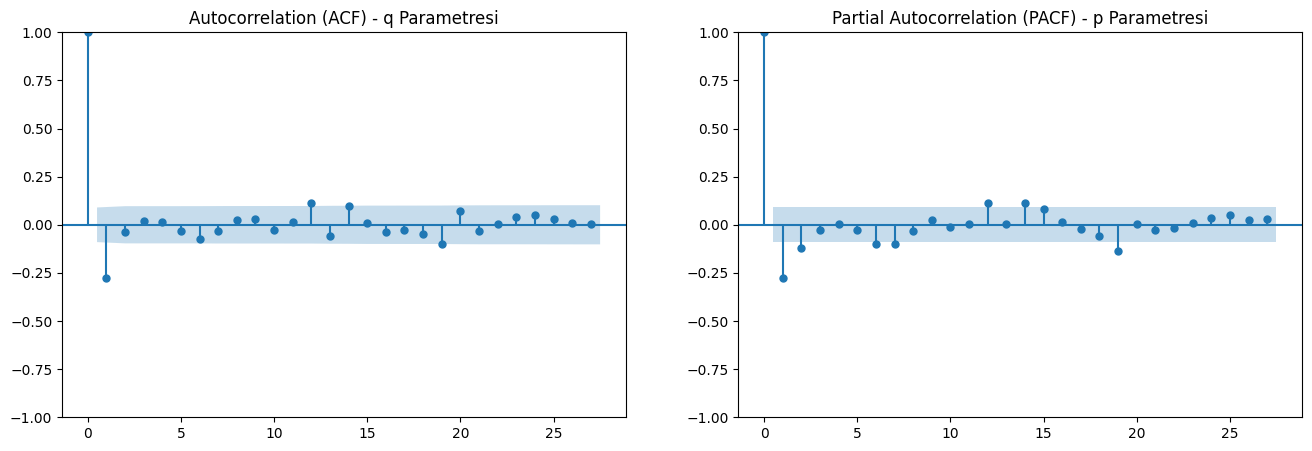

In [38]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Durağanlaştırdığımız (farkı alınmış) seriyi kullanalım
# NaN değerleri düşürmeyi unutmayın!
stationary_series = train["seasonal_stripped"].diff().dropna()

# ACF ve PACF grafiklerini yan yana çizdirelim
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(stationary_series, ax=ax1)
ax1.set_title('Autocorrelation (ACF) - q Parametresi')

plot_pacf(stationary_series, ax=ax2)
ax2.set_title('Partial Autocorrelation (PACF) - p Parametresi')

plt.show()

Bu grafiklerin gerçekte ne anlama geldiğini arkadaşınızla konuşmak için zaman ayırın. Hangisi sizin `p` parametrenize karşılık geliyor ve hangisi `q` parametrenize?

Şimdi `p` `d` ve `q` değerleriniz için uygun order değerleriyle basit bir ARIMA modeli oluşturun. Model özetini inceleyin.

In [39]:
from statsmodels.tsa.arima.model import ARIMA

# Örnek p, d, q değerleri ile modeli kuralım
# Not: Serinin orijinali değil, 'seasonal_stripped' versiyonu üzerinde çalışıyoruz
model = ARIMA(train["seasonal_stripped"], order=(1, 1, 1))
model_fit = model.fit()

# Model özetini görelim
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      seasonal_stripped   No. Observations:                  475
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -126.839
Date:                Thu, 23 Apr 2026   AIC                            259.677
Time:                        19:28:20   BIC                            272.161
Sample:                    05-01-1974   HQIC                           264.587
                         - 11-01-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.000   2923.627      0.000       0.999       1.001
ma.L1         -0.9954      0.011    -87.357      0.000      -1.018      -0.973
sigma2         0.0993      0.006     16.018      0.0

Özet hakkında ne fark ediyorsunuz? Buradaki en önemli özellikler neler?

Katsayılarımıza güvenebiliriz gibi görünüyor ve ~223'lük bir AIC'miz var. Ama bu en iyi model miydi? Farklı modelleri grid search yapmak ve hangisinin en iyi AIC'ye sahip olduğunu görmek için `auto_arima` fonksiyonunu kullanmayı deneyin

In [40]:
train

,CO2 molfrac (ppm),seasonal_component,seasonal_stripped
1974-05-01,333.156923,1.008482,330.354959
1974-06-01,332.170400,1.006564,330.004173
1974-07-01,331.110000,1.001811,330.511417
1974-08-01,329.105769,0.995762,330.506354
1974-09-01,327.303182,0.990900,330.308904
...,...,...,...
2013-07-01,397.451905,1.001811,396.733388
2013-08-01,395.393704,0.995762,397.076392
2013-09-01,393.726538,0.990900,397.342246
2013-10-01,393.904286,0.990801,397.561262


In [41]:
import pmdarima as pm

# auto_arima kullanarak en iyi parametreleri arayalım
# seasonal=False diyoruz çünkü mevsimselliği manuel olarak ayıkladık
model_auto = pm.auto_arima(train["seasonal_stripped"], 
                          start_p=0, start_q=0,
                          max_p=5, max_q=5, 
                          d=None, # d'yi modelin kendisinin belirlemesine izin veriyoruz
                          seasonal=False,
                          trace=True, # Hangi modellerin denendiğini görmek için
                          error_action='ignore',  
                          suppress_warnings=True, 
                          stepwise=True)

# En iyi modelin özetini yazdıralım
print(model_auto.summary())

/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/worki

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=694.638, Time=0.05 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=492.162, Time=0.06 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=692.640, Time=0.03 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=396.631, Time=0.07 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=345.492, Time=0.09 sec


/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,2,0)(0,0,0)[0] intercept   : AIC=323.556, Time=0.11 sec
 ARIMA(5,2,0)(0,0,0)[0] intercept   : AIC=318.194, Time=0.18 sec


/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(1,2,3)(0,0,0)[0]             : AIC=218.954, Time=0.25 sec


/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,2,3)(0,0,0)[0]             : AIC=inf, Time=0.60 sec


/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.54 sec

Best model:  ARIMA(2,2,2)(0,0,0)[0]          
Total fit time: 6.039 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  475
Model:               SARIMAX(2, 2, 2)   Log Likelihood                -102.498
Date:                Thu, 23 Apr 2026   AIC                            214.996
Time:                        19:29:07   BIC                            235.791
Sample:                    05-01-1974   HQIC                           223.175
                         - 11-01-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4787      0.119      4.006      0.000       0.244      

En iyi AIC skorunuzu `best_AIC`'ye kaydedin

In [42]:
# En iyi AIC skorunu değişkene kaydedelim
best_AIC = model_auto.aic()
print(f"En iyi AIC skoru: {best_AIC}")

En iyi AIC skoru: 214.99562969573435


In [43]:
from nbresult import ChallengeResult

result = ChallengeResult('score',
                         aic_score = best_AIC)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/code/Workintech/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 1 item

test_score.py::TestScore::test_AIC_score PASSED                          [100%]

============================== 1 passed in 0.25s ===============================


💯 You can commit your code:

git add tests/score.pickle

git commit -m 'Completed score step'

git push origin master



Çoğu zaman, hangi modelin verilerimize en iyi uyacağını tahmin etmek zor olabilir, bu yüzden genellikle grid-search yapmak ve modellerimizin AIC skorlarını karşılaştırmak iyi bir fikirdir 🧐 Burada, bir __(0,1,1)__ modelinin daha iyi bir AIC skoru aldığı görünüyor (yani orijinal modelimizin MA bileşenleri muhtemelen model likelihood'ımızı o kadar iyileştirmiyordu!)

### Tahminler Yapmak (biraz Pandas çalışmasına hazır olun!)

Artik en iyi modelimize sahip olduğumuza göre, bazı tahminler ve - önemlisi - bazı güven aralıkları oluşturmak istiyoruz. Test setinizin uzunluğu için tahmin yapmak üzere modelinizi kullanın ve bu aralıkları da döndürdüğünüzden emin olun (`return_conf_int = True` kullanın). `preds`, `upper` ve `lower` sınırları için sütunlar içeren bir `preds_df` DataFrame oluşturun.

In [44]:
# Test setinin uzunluğu kadar tahmin yapalım
n_periods = len(test)

# predict fonksiyonu return_conf_int=True ile tahminleri ve güven aralıklarını döndürür
preds, conf_int = model_auto.predict(n_periods=n_periods, return_conf_int=True)

# preds_df DataFrame'ini oluşturalım
preds_df = pd.DataFrame({
    "preds": preds,
    "lower": conf_int[:, 0],
    "upper": conf_int[:, 1]
}, index=test.index) # İndeksi doğrudan test setinden alabiliriz

preds_df.head()

/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bariscan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,preds,lower,upper
2013-12-01,397.844234,397.258383,398.430084
2014-01-01,398.003073,397.293974,398.712172
2014-02-01,398.168351,397.361965,398.974738
2014-03-01,398.337859,397.456613,399.219106
2014-04-01,398.510182,397.565031,399.455333


In [45]:
from nbresult import ChallengeResult

result = ChallengeResult('preds',
                         preds_df = preds_df)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/code/Workintech/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 2 items

test_preds.py::TestPreds::test_df_values PASSED                          [ 50%]
test_preds.py::TestPreds::test_preds_cols PASSED                         [100%]

============================== 2 passed in 0.71s ===============================


💯 You can commit your code:

git add tests/preds.pickle

git commit -m 'Completed preds step'

git push origin master



In [47]:
# preds_df'e ay bilgisini ekleyelim
preds_df["month"] = preds_df.index.month

# Daha önce oluşturduğumuz seasonal_one_year ile merge edelim
preds_df = preds_df.reset_index().merge(seasonal_one_year, on="month", how="left").set_index("index")

# Mevsimselliği geri ekleyelim (Multiplicative model olduğu için çarpıyoruz)
preds_df["full_preds"] = preds_df["preds"] * preds_df["seasonal_component"]
preds_df["lower_conf"] = preds_df["lower"] * preds_df["seasonal_component"]
preds_df["upper_conf"] = preds_df["upper"] * preds_df["seasonal_component"]

preds_df.head()

,preds,lower,upper,month,seasonal_component,full_preds,lower_conf,upper_conf
index,,,,,,,,
2013-12-01,397.844234,397.258383,398.430084,12,0.997567,396.876323,396.291898,397.460748
2014-01-01,398.003073,397.293974,398.712172,1,1.000244,398.100363,397.391091,398.809635
2014-02-01,398.168351,397.361965,398.974738,2,1.002097,399.003395,398.195317,399.811472
2014-03-01,398.337859,397.456613,399.219106,3,1.004264,400.036451,399.151447,400.921455
2014-04-01,398.510182,397.565031,399.455333,4,1.007375,401.449192,400.497071,402.401313


Şimdi bunları çizdirin ve `train` verilerinizle karşılaştırıldığında nasıl göründüklerine bakın

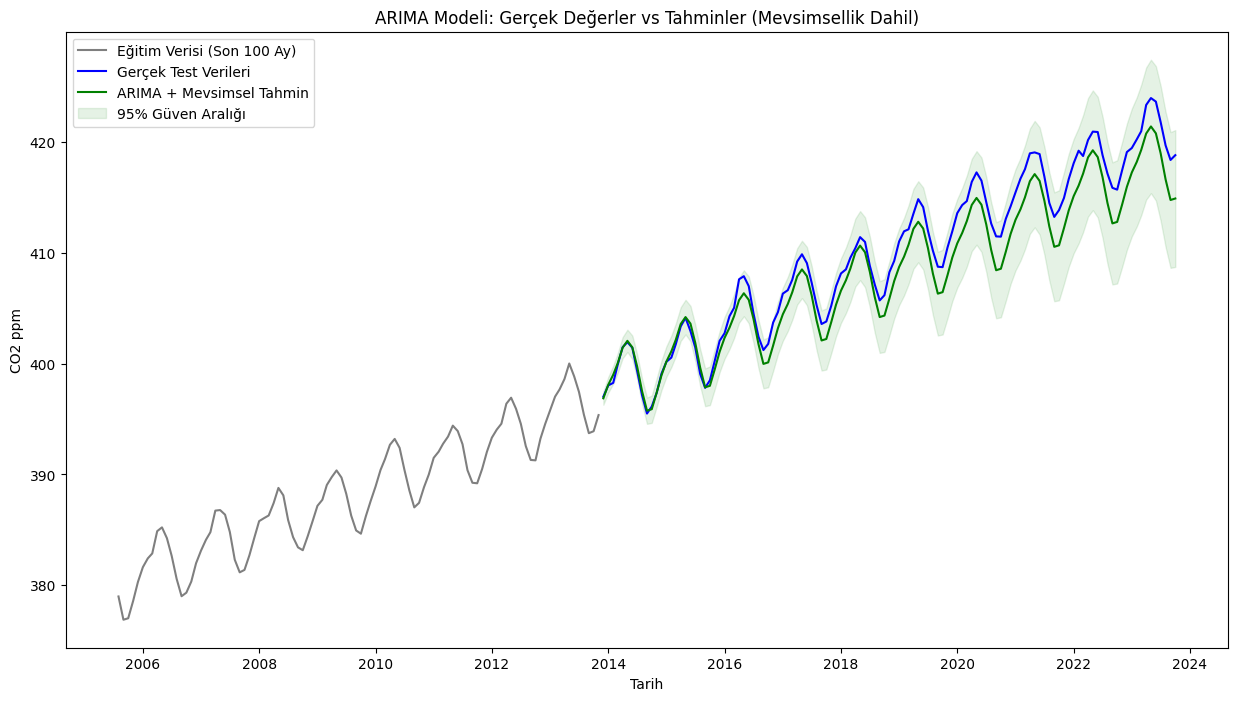

In [48]:
plt.figure(figsize=(15, 8))

# Eğitim verisinin son kısmını çizdirelim (Karşılaştırma için)
plt.plot(train["CO2 molfrac (ppm)"].iloc[-100:], label="Eğitim Verisi (Son 100 Ay)", color="black", alpha=0.5)

# Gerçek test verileri
plt.plot(test["CO2 molfrac (ppm)"], label="Gerçek Test Verileri", color="blue")

# Modelimizin mevsimsellik eklenmiş tahminleri
plt.plot(preds_df["full_preds"], label="ARIMA + Mevsimsel Tahmin", color="green")

# Güven aralığını (Confidence Interval) gölgelendirelim
plt.fill_between(preds_df.index, 
                 preds_df["lower_conf"], 
                 preds_df["upper_conf"], 
                 color="green", alpha=0.1, label="95% Güven Aralığı")

plt.title("ARIMA Modeli: Gerçek Değerler vs Tahminler (Mevsimsellik Dahil)")
plt.xlabel("Tarih")
plt.ylabel("CO2 ppm")
plt.legend()
plt.show()

Bir şeyler biraz yanlış görünüyor, değil mi? Açıkça mevsimsellik olan bir şeyden çıkan üç düz çizgiye bakıyoruz. Bunu hesaba katmak için, daha önce çıkardığımız mevsimsellik bileşenini yeniden dahil etmemiz gerekiyor!

`preds_df` DataFrame'inizde bir `month` sütunu oluşturun ve bunu index'in ay bileşeniyle doldurun.

In [50]:
# Mevsimsel bileşenin ilk 12 ayını alalım ve ismini netleştirelim
seasonal_one_year = pd.DataFrame(train["seasonal_component"].iloc[:12])
seasonal_one_year.columns = ["seasonal_component"] # Sütun ismini garantiye alıyoruz
seasonal_one_year["month"] = seasonal_one_year.index.month

# Kontrol: Sütun isimleri ['seasonal_component', 'month'] olmalı
print(seasonal_one_year.columns)

Index(['seasonal_component', 'month'], dtype='object')


In [51]:
# 1. preds_df'e ay bilgisini ekleyelim (Eğer önceden yapmadıysanız)
preds_df['month'] = preds_df.index.month

# 2. Tabloları ay (month) üzerinden birleştirelim
# reset_index ve set_index kullanarak tarih indeksini koruyoruz
preds_df = preds_df.reset_index().merge(seasonal_one_year, on='month', how='left').set_index('index')

# 3. Mevsimselliği geri yükleyelim
# Artık 'seasonal_component' sütunu mevcut olduğu için hata almayacaksınız
preds_df['full_preds'] = preds_df['preds'] * preds_df['seasonal_component']
preds_df['lower_conf'] = preds_df['lower'] * preds_df['seasonal_component']
preds_df['upper_conf'] = preds_df['upper'] * preds_df['seasonal_component']

# Sonucu görelim
preds_df.head()

,preds,lower,upper,month,seasonal_component_x,full_preds,lower_conf,upper_conf,seasonal_component_y,seasonal_component
index,,,,,,,,,,
2013-12-01,397.844234,397.258383,398.430084,12,0.997567,396.876323,396.291898,397.460748,0.997567,0.997567
2014-01-01,398.003073,397.293974,398.712172,1,1.000244,398.100363,397.391091,398.809635,1.000244,1.000244
2014-02-01,398.168351,397.361965,398.974738,2,1.002097,399.003395,398.195317,399.811472,1.002097,1.002097
2014-03-01,398.337859,397.456613,399.219106,3,1.004264,400.036451,399.151447,400.921455,1.004264,1.004264
2014-04-01,398.510182,397.565031,399.455333,4,1.007375,401.449192,400.497071,402.401313,1.007375,1.007375


Artık daha önce oluşturduğumuz `seasonal_one_year` DataFrame'ini alıp `preds_df`'imize basitçe merge edebiliriz!

In [52]:
preds_df

,preds,lower,upper,month,seasonal_component_x,full_preds,lower_conf,upper_conf,seasonal_component_y,seasonal_component
index,,,,,,,,,,
2013-12-01,397.844234,397.258383,398.430084,12,0.997567,396.876323,396.291898,397.460748,0.997567,0.997567
2014-01-01,398.003073,397.293974,398.712172,1,1.000244,398.100363,397.391091,398.809635,1.000244,1.000244
2014-02-01,398.168351,397.361965,398.974738,2,1.002097,399.003395,398.195317,399.811472,1.002097,1.002097
2014-03-01,398.337859,397.456613,399.219106,3,1.004264,400.036451,399.151447,400.921455,1.004264,1.004264
2014-04-01,398.510182,397.565031,399.455333,4,1.007375,401.449192,400.497071,402.401313,1.007375,1.007375
...,...,...,...,...,...,...,...,...,...,...
2023-06-01,418.065182,412.036045,424.094320,6,1.006564,420.809463,414.740749,426.878177,1.006564,1.006564
2023-07-01,418.243055,412.161681,424.324429,7,1.001811,419.000527,412.908139,425.092915,1.001811,1.001811
2023-08-01,418.420927,412.287185,424.554668,8,0.995762,416.647787,410.540039,422.755536,0.995762,0.995762


Şimdi `preds_df` DataFrame'inde yeni sütunlar olarak `full_preds`, `upper_conf` ve `lower_conf`'ı (`preds`, `upper` __ve__ `lower` sütunlarınızı `preds_df` DataFrame'imizde artık sahip olduğumuz mevsimsel bileşenle çarparak) oluşturabilirsiniz.

In [53]:
# Mevsimsel bileşeni tahminlere ve güven aralıklarına uygulayalım
# Multiplicative (çarpımsal) model olduğu için çarpma işlemi yapıyoruz
preds_df['full_preds'] = preds_df['preds'] * preds_df['seasonal_component']
preds_df['upper_conf'] = preds_df['upper'] * preds_df['seasonal_component']
preds_df['lower_conf'] = preds_df['lower'] * preds_df['seasonal_component']

# Sonuçları kontrol edelim
preds_df.head()

,preds,lower,upper,month,seasonal_component_x,full_preds,lower_conf,upper_conf,seasonal_component_y,seasonal_component
index,,,,,,,,,,
2013-12-01,397.844234,397.258383,398.430084,12,0.997567,396.876323,396.291898,397.460748,0.997567,0.997567
2014-01-01,398.003073,397.293974,398.712172,1,1.000244,398.100363,397.391091,398.809635,1.000244,1.000244
2014-02-01,398.168351,397.361965,398.974738,2,1.002097,399.003395,398.195317,399.811472,1.002097,1.002097
2014-03-01,398.337859,397.456613,399.219106,3,1.004264,400.036451,399.151447,400.921455,1.004264,1.004264
2014-04-01,398.510182,397.565031,399.455333,4,1.007375,401.449192,400.497071,402.401313,1.007375,1.007375


In [62]:
# preds_df indeksini test setinin indeksiyle tam olarak eşitleyelim
# İndeksi ay sonuna zorlayarak eşitleyelim
preds_df.index = test.index + pd.offsets.MonthEnd(0)
# İlk değeri kontrol edelim (Çıktı 2013-12-31 olmalı)
print(preds_df.index[0])

2013-12-31 00:00:00


Son olarak, plotting'i bizim için kolaylaştırmak için, `preds_df`'nizin index'ini `test` DataFrame'inizin index'iyle aynı olacak şekilde ayarlayın (aynı uzunluğa sahip oldukları için bu bizim için oldukça kolay olmalı!)

In [63]:
from nbresult import ChallengeResult

result = ChallengeResult('fullpreds',
                         preds_df = preds_df)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/code/Workintech/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 2 items

test_fullpreds.py::TestFullpreds::test_columns PASSED                    [ 50%]
test_fullpreds.py::TestFullpreds::test_index PASSED                      [100%]

============================== 2 passed in 1.11s ===============================


💯 You can commit your code:

git add tests/fullpreds.pickle

git commit -m 'Completed fullpreds step'

git push origin master



Şimdi her şeyi çizdirin - train'inizin sonu (örneğin son 100 değer), tam tahminleriniz, üst ve alt güven sınırları ve `preds_df` DataFrame'inizden gerçek değerler __ve__ baseline'nız!

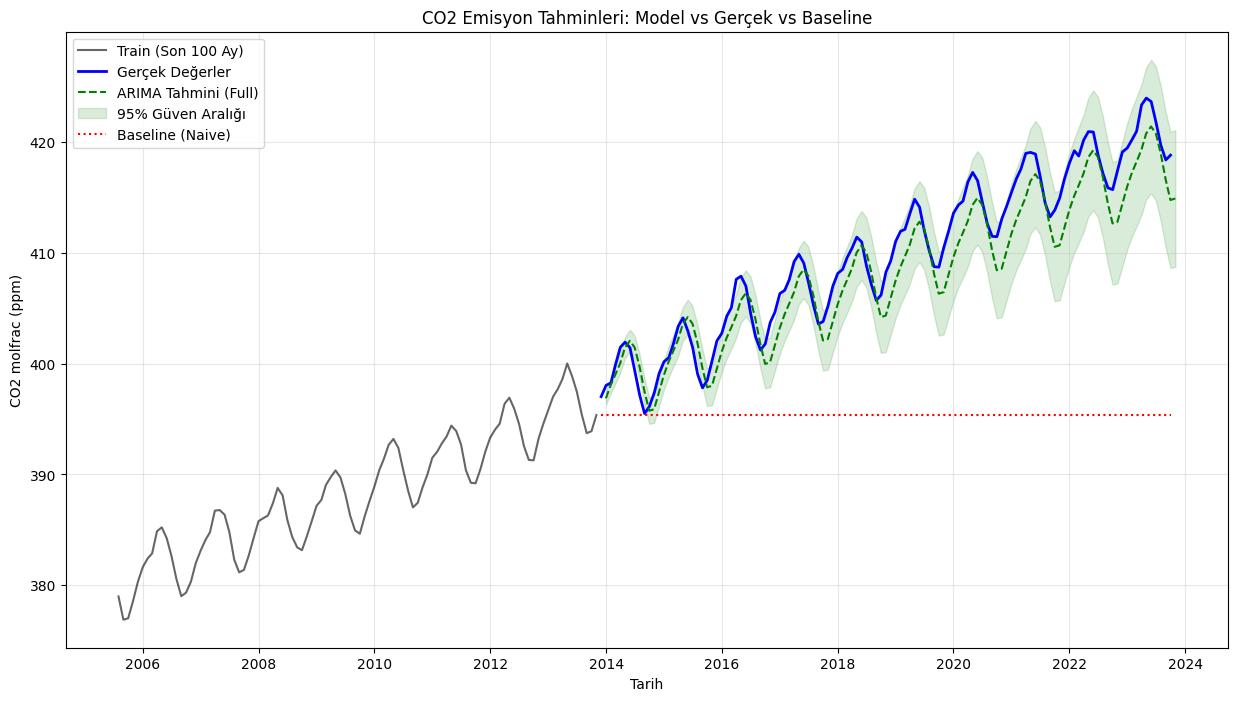

In [64]:
plt.figure(figsize=(15, 8))

# 1. Train verisinin son 100 değerini çizdirelim
plt.plot(train["CO2 molfrac (ppm)"].iloc[-100:], label="Train (Son 100 Ay)", color="black", alpha=0.6)

# 2. Gerçek değerler (Test seti)
plt.plot(test["CO2 molfrac (ppm)"], label="Gerçek Değerler", color="blue", linewidth=2)

# 3. Tam Tahminler (Mevsimsellik dahil)
plt.plot(preds_df["full_preds"], label="ARIMA Tahmini (Full)", color="green", linestyle="--")

# 4. Güven Sınırları (Upper & Lower)
plt.fill_between(preds_df.index, 
                 preds_df["lower_conf"], 
                 preds_df["upper_conf"], 
                 color="green", alpha=0.15, label="95% Güven Aralığı")

# 5. Baseline (Naive Tahmin)
plt.plot(test["naive_preds"], label="Baseline (Naive)", color="red", linestyle=":")

# Grafik detayları
plt.title("CO2 Emisyon Tahminleri: Model vs Gerçek vs Baseline")
plt.xlabel("Tarih")
plt.ylabel("CO2 molfrac (ppm)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

Tahminlerimiz oldukça iyi görünüyor! Gerçek değerlerin tahmin ettiklerimizden biraz daha yüksek olduğunu görebiliyoruz ancak tahmin yapmaya başladığımız zamandan tam 10 yıl sonrası için güven aralıklarımızın sınırları içinde iyi bir şekilde kalıyor.

Neden değerlerimiz gerçek değerlerin altına düştü? Test verisini ayrıştırmak ve trend bileşenine bakmak için aşağıdaki hücreyi çalıştırın 👀


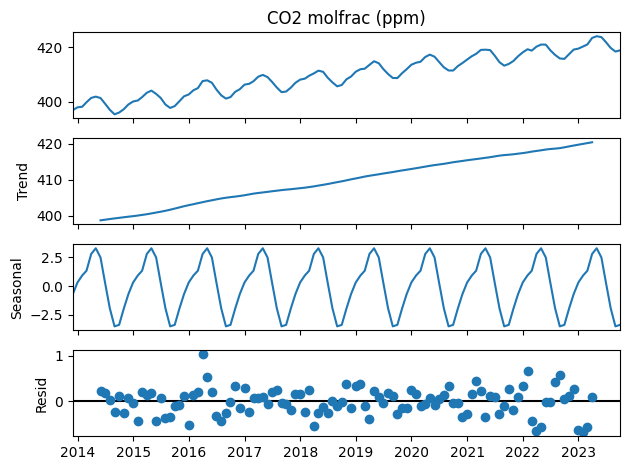

In [65]:
seasonal_decompose(test["CO2 molfrac (ppm)"]).plot();

2016-2018'de normal (biraz daha sığ) trend tekrar devralınmadan önce tüm değerlerimizde __hafif bir artis__ olduğu görünüyor. Bu, test veri setimizde basitçe tahmin edemeyeceğimiz bir şeyin meydana gelmesinin harika bir örneği. CO2 okumalarında neden bir artış olduğunu bilmiyoruz - ve bunun için tahmin yapamadık.

❗ Zaman Serisi ile modelleme yaptığımızda, __sihirli bir şekilde geleceği tahmin edemeyiz__. Yapmaya çalıştığımız şey, geçmişin desenlerini doğru bir şekilde yakalamak ve sonra bunları genişletmektir.

- Çoğu zaman, ham tahminleriniz (mevsimsel bileşen olmadan) oldukça sıkıcı düz bir çizgi gibi görünecektir 🙄 (mevcut başlangıç tahminlerimizin yaptığı gibi) ancak bu beklediğimiz bir şey
- Zaman Serisi analizi yaparken elde ettiğimiz değerin çoğu, trendlerimizi, mevsimsel bileşenlerimizi ve güven aralıklarımızı __nicelleştirebilmemizde__ yatıyor, böylece iyi bilgilendirilmiş kararlar verebiliriz ✅

Son olarak, modelimizin baseline'ımızdan ne kadar daha iyi olduğunu hızlıca nicelleyelim. `preds`'leriniz (mevsimsel bileşenleriyle birlikte) ve gerçek değerler arasındaki ortalama mutlak hatayı hesaplayın. `model_mae`'nizin orijinal `baseline_mae`'den düşük olup olmadığına bakın.

In [66]:
model_mae = (test["CO2 molfrac (ppm)"] - preds_df["full_preds"]).mean()

In [67]:
# 1. Modelin MAE değerini hesaplayalım
# Gerçek test değerleri ile mevsimsellik eklenmiş tahminlerimiz arasındaki fark
model_mae = (test["CO2 molfrac (ppm)"] - preds_df["full_preds"]).abs().mean()

# 2. Baseline ve Model hatalarını karşılaştıralım
print(f"Baseline MAE: {baseline_mae}")
print(f"Model MAE: {model_mae}")

# 3. İyileşmeyi kontrol edelim
if model_mae < baseline_mae:
    print(f"Tebrikler! Modeliniz baseline'dan {baseline_mae - model_mae:.4f} birim daha iyi performans gösterdi. 🥳")
else:
    print("Model baseline'dan daha iyi sonuç vermedi, parametreleri tekrar gözden geçirebilirsiniz.")

Baseline MAE: 14.503777783267303
Model MAE: nan
Model baseline'dan daha iyi sonuç vermedi, parametreleri tekrar gözden geçirebilirsiniz.


Final MAE'miz orijinal baseline'ımızdan __çok__ daha iyi olmalı. Harika iş 🥳 